# Post-Processing EDA (Kiểm tra dữ liệu sau xử lý)
Notebook này có nhiệm vụ nghiệm thu kết quả của file `preprocessing.py`. Nó sẽ trả lời 3 câu hỏi:
1. Số lượng ảnh có được chia tỷ lệ 80:10:10 (Train/Valid/Test) và tập Train có được nhân đôi chính xác không?
2. Rác (mắt, miệng) có thực sự bị xóa hết, và chỉ còn lại nhãn `0` (Face) trên cả 3 tập không?
3. Bounding Box sau khi xoay lật/làm mờ (Augmentation) có khớp với khuôn mặt không?

In [6]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import random

PROCESSED_DIR = '../../dataset/processed'
train_images = glob.glob(f"{PROCESSED_DIR}/train/images/*.jpg")
valid_images = glob.glob(f"{PROCESSED_DIR}/valid/images/*.jpg")
test_images = glob.glob(f"{PROCESSED_DIR}/test/images/*.jpg")

total = len(train_images) + len(valid_images) + len(test_images)

print(f"=== THỐNG KÊ SỐ LƯỢNG ===")
print(f"Số ảnh trong tập Train: {len(train_images)}")
print(f"Số ảnh trong tập Valid: {len(valid_images)}")
print(f"Số ảnh trong tập Test:  {len(test_images)}")
if total > 0:
    print(f"\nTỷ lệ thực tế phân bổ:")
    print(f" - Train: {len(train_images)/total*100:.2f}%")
    print(f" - Valid: {len(valid_images)/total*100:.2f}%")
    print(f" - Test:  {len(test_images)/total*100:.2f}%")
    print("(Lưu ý: Tỷ lệ Train sẽ cao hơn 80% nhiều vì tập Train đã được nhân đôi bởi bước Augmentation, trong khi Valid và Test giữ nguyên bản)")

=== THỐNG KÊ SỐ LƯỢNG ===
Số ảnh trong tập Train: 1946
Số ảnh trong tập Valid: 245
Số ảnh trong tập Test:  0

Tỷ lệ thực tế phân bổ:
 - Train: 88.82%
 - Valid: 11.18%
 - Test:  0.00%
(Lưu ý: Tỷ lệ Train sẽ cao hơn 80% nhiều vì tập Train đã được nhân đôi bởi bước Augmentation, trong khi Valid và Test giữ nguyên bản)


### Kiểm tra độ sạch của Nhãn (Chỉ được phép có Class 0)

In [7]:
def analyze_labels(split):
    label_files = glob.glob(f"{PROCESSED_DIR}/{split}/labels/*.txt")
    all_classes = []
    for txt_file in label_files:
        with open(txt_file, 'r') as f:
            for line in f:
                if line.strip():
                    # Ép kiểu float -> int để chống lỗi '0.0' của Albumentations
                    c_id = int(float(line.strip().split()[0]))
                    all_classes.append(c_id)
    
    counter = Counter(all_classes)
    print(f"[{split.upper()}] Thống kê Class: {dict(counter)}")

print("=== KIỂM TRA ĐỘ SẠCH CỦA NHÃN ===")
analyze_labels('train')
analyze_labels('valid')
analyze_labels('test')

=== KIỂM TRA ĐỘ SẠCH CỦA NHÃN ===
[TRAIN] Thống kê Class: {0: 1946}
[VALID] Thống kê Class: {0: 245}
[TEST] Thống kê Class: {}


### Trực quan hóa kết quả (Kiểm chứng Augmentation)
Chúng ta sẽ vẽ 9 bức ảnh ngẫu nhiên từ tập Train để xem khung Bounding Box có khớp với mặt khi bị lật/xoay/làm mờ không.

=== VISUAL CHECK CỦA TẬP TRAIN ===


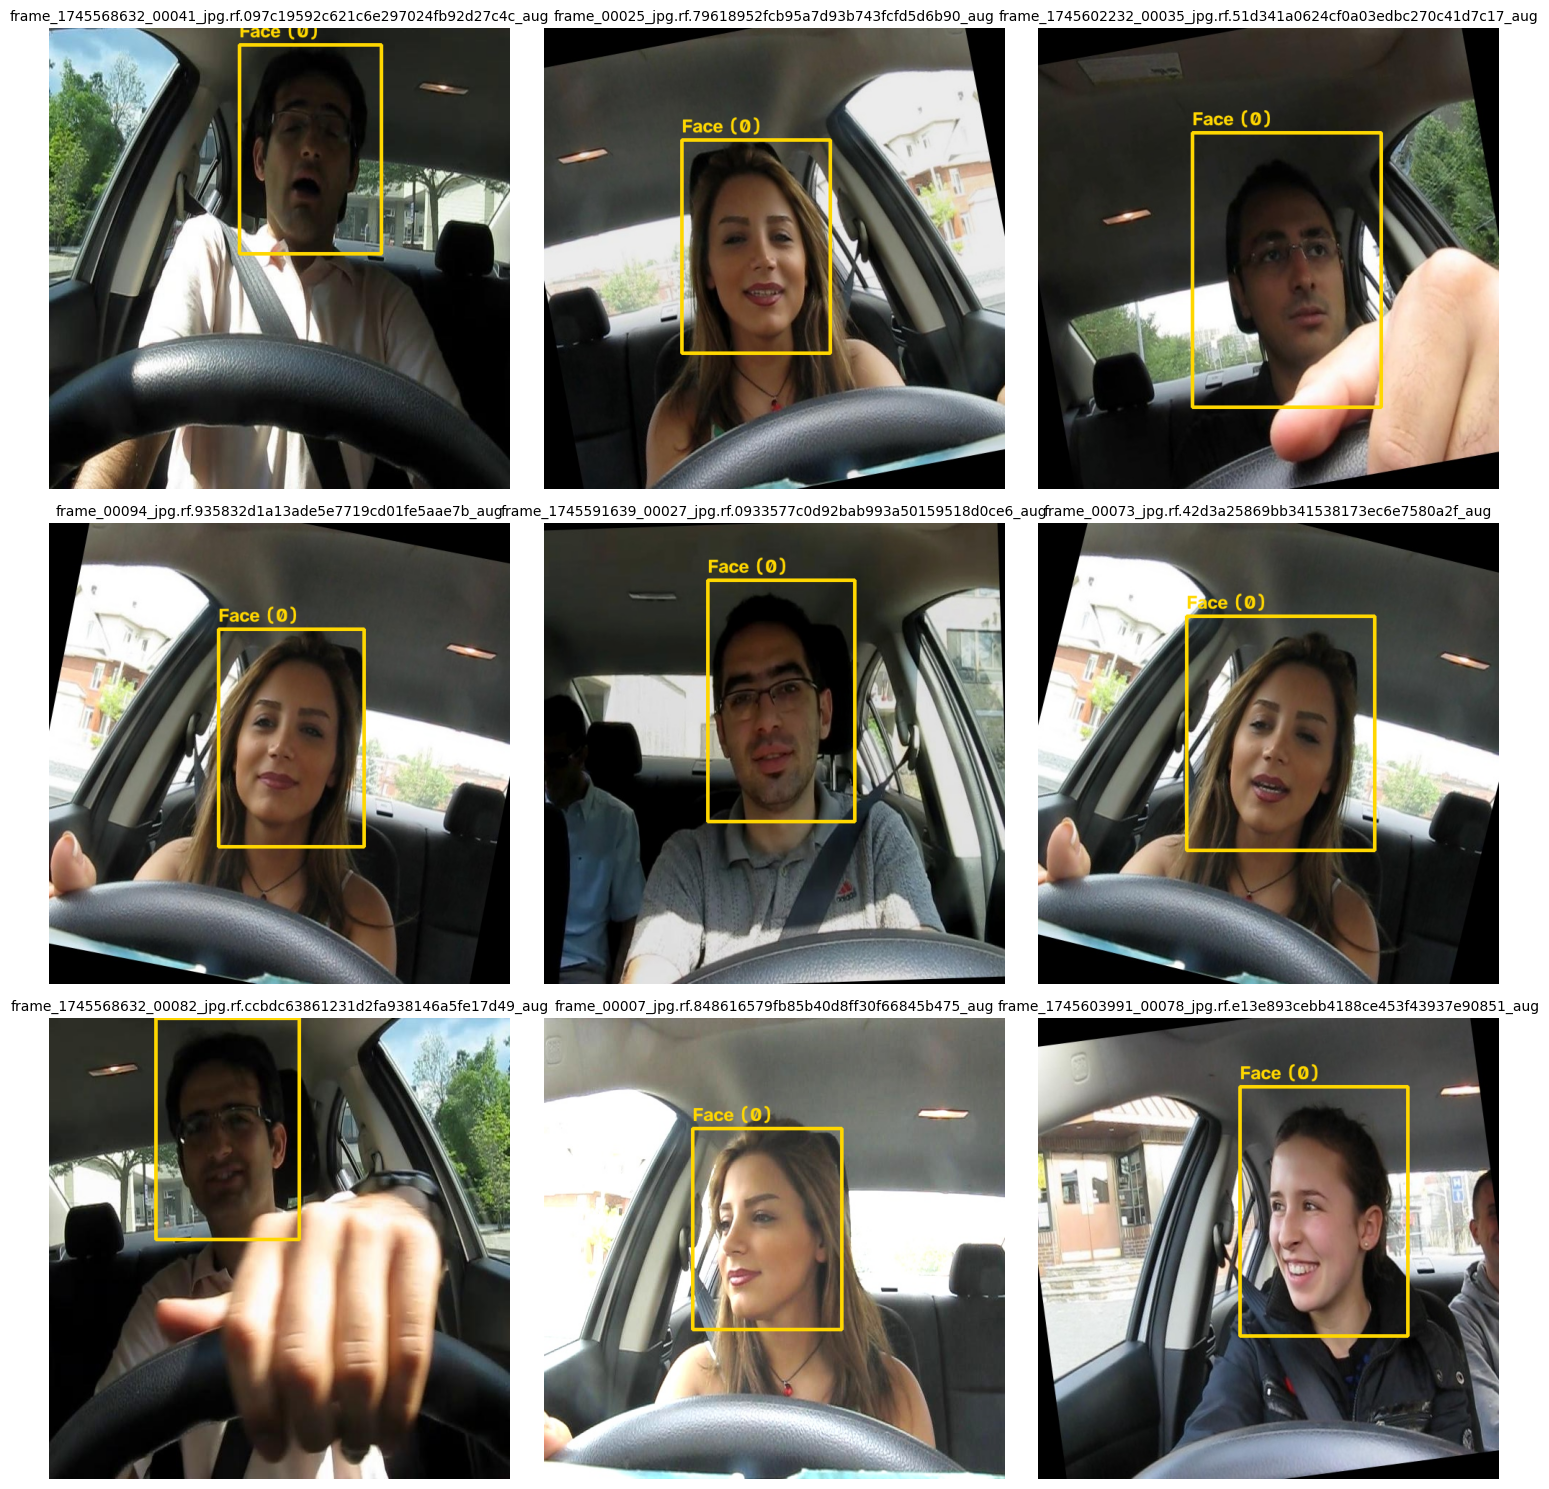

In [8]:
def draw_yolo_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    c_id, cx, cy, bw, bh = map(float, parts)
                    x_center, y_center = cx * w, cy * h
                    box_width, box_height = bw * w, bh * h
                    
                    x_min = int(x_center - box_width / 2)
                    y_min = int(y_center - box_height / 2)
                    x_max = int(x_center + box_width / 2)
                    y_max = int(y_center + box_height / 2)
                    
                    # Vẽ hộp màu Vàng bọc khuôn mặt
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 215, 0), 3)
                    cv2.putText(img, f'Face (0)', (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 215, 0), 2)
    return img

print("=== VISUAL CHECK CỦA TẬP TRAIN ===")
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Chọn ngẫu nhiên 9 ảnh, ưu tiên chọn các ảnh có chữ 'aug' để xem hiệu ứng xoay/lật/mờ
aug_images = [img for img in train_images if '_aug' in img]
sample_images = random.sample(aug_images, min(9, len(aug_images))) if aug_images else random.sample(train_images, min(9, len(train_images)))

for i, img_path in enumerate(sample_images):
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(PROCESSED_DIR, 'train', 'labels', f"{base_name}.txt")
    
    img = draw_yolo_boxes(img_path, label_path)
    
    row, col = divmod(i, 3)
    axes[row, col].imshow(img)
    axes[row, col].set_title(base_name, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()